In [1]:
from functools import partial
from mc_core.sampling.exponential import *
from mc_core.utils.montecarlo import *
from matplotlib import pyplot as plt
from mc_core.utils.randomVariable import *
import scipy.stats as scistats
import matplotlib

## Exponential Distribution

## Direct Sampling

In [2]:
num_samples = 10000
lambda_parameter = 2
exponential_samples = sample_exponential(lambda_parameter, num_samples)

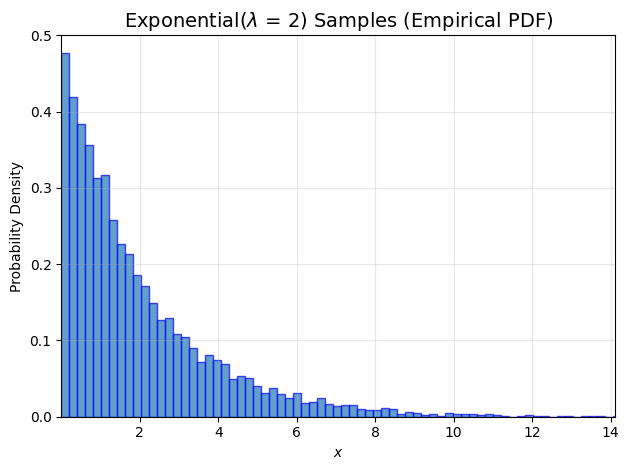

In [3]:
visualize_samples(exponential_samples, "Exponential($\lambda$ = 2)")

## Empirical vs Theoretical Distribution

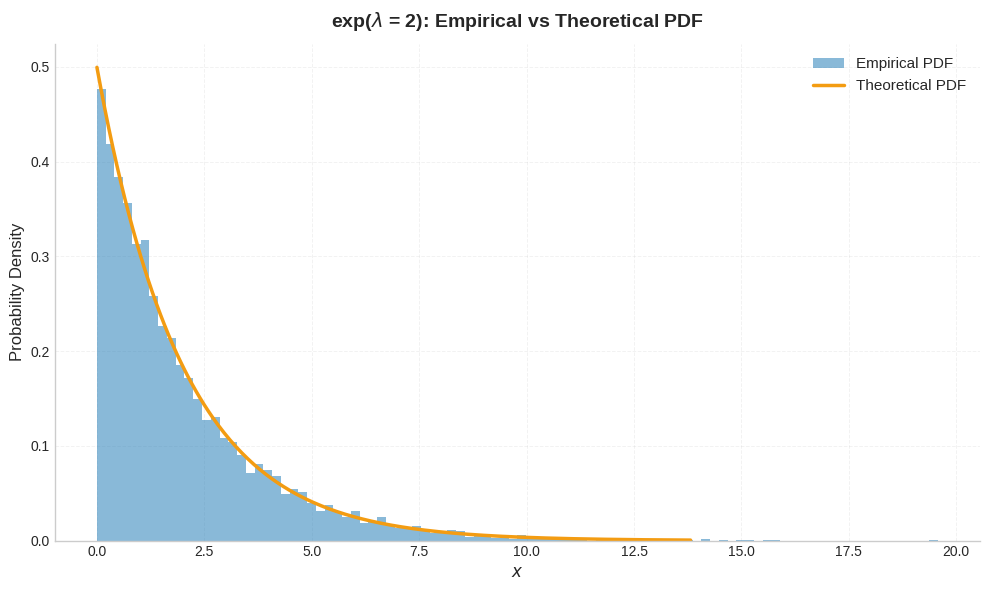

In [4]:
expon_rv = scistats.expon(scale=lambda_parameter)
plot_empirical_and_theoretical_pdf(exponential_samples,expon_rv,dist_name=f"exp($\lambda$ = {lambda_parameter})",save_path="images/exponential/EmpvsTheo_exp.png")

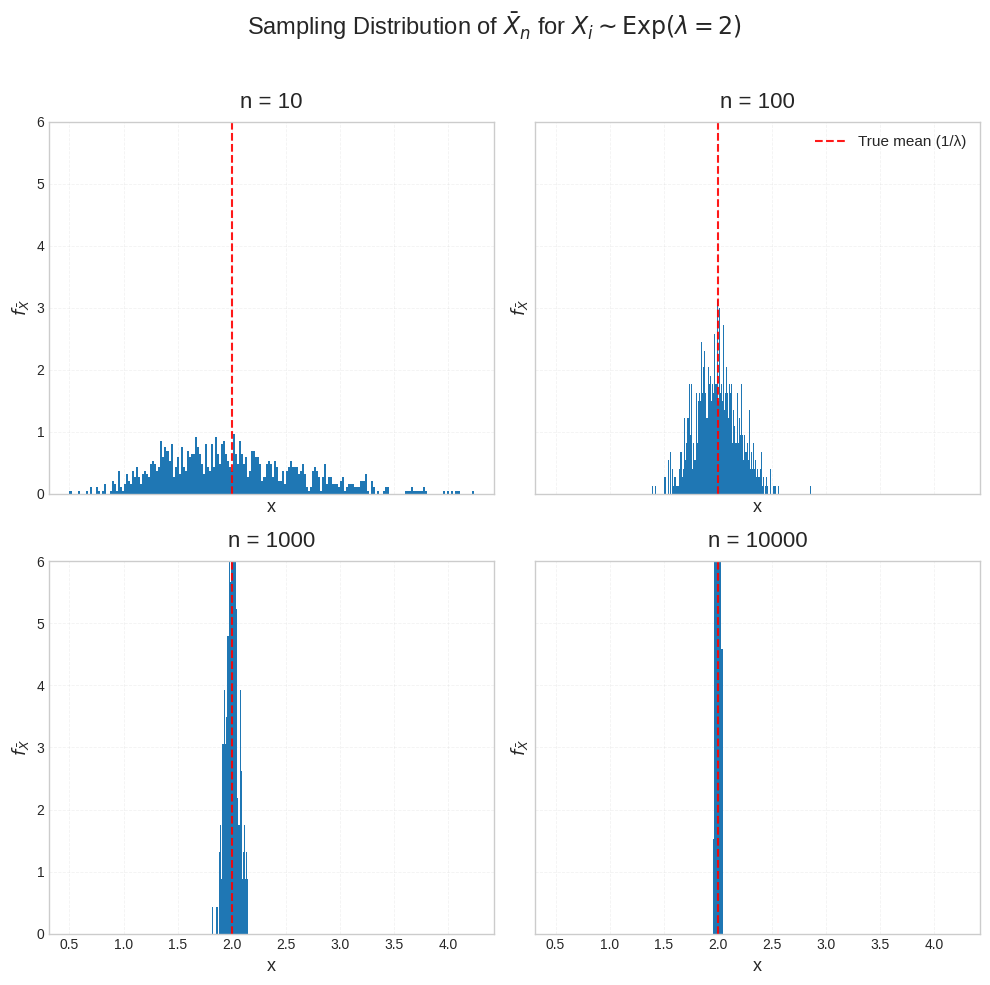

In [5]:
exp_gen = partial(sample_exponential, lambda_parameter)
nsamples = np.array([[10, 100], [1000, 10000]])
ntrials = 1000
true_mean = lambda_parameter

# plt.style.use('seaborn-v0_8-talk')
fig, axs = plt.subplots(2, 2, figsize=(10, 10), sharex=True, sharey=True)

for i, n in np.ndenumerate(nsamples):
    estimates = sampling_distribution(n, ntrials, exp_gen, lambda x: x)
    
    axs[i].hist(estimates, bins=200, density=True)
    # True mean line
    axs[i].axvline(true_mean, color='red', lw=1.5, linestyle='--', alpha=0.9, label='True mean (1/λ)')
    
    axs[i].set_title(f"n = {n}", fontsize=16, pad=10)
    axs[i].set_xlabel("x", fontsize=13)
    axs[i].set_ylabel("$f_{\\bar{X}}$", fontsize=13)
    axs[i].grid(alpha=0.25, linestyle='--', linewidth=0.6)
    axs[i].set_ylim(0, 6)

fig.suptitle(r"Sampling Distribution of $\bar{X}_n$ for $X_i \sim \mathrm{Exp}(\lambda=2)$",
             fontsize=17, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
# Legend (once, in upper right subplot)
axs[0, 1].legend(frameon=False, fontsize=11, loc='best')
fig.savefig("images/exponential/WLLN_exp.png", dpi=300, bbox_inches='tight')
plt.show()


## Running Monte Carlo Estimate of the Mean (Law of Large Numbers)

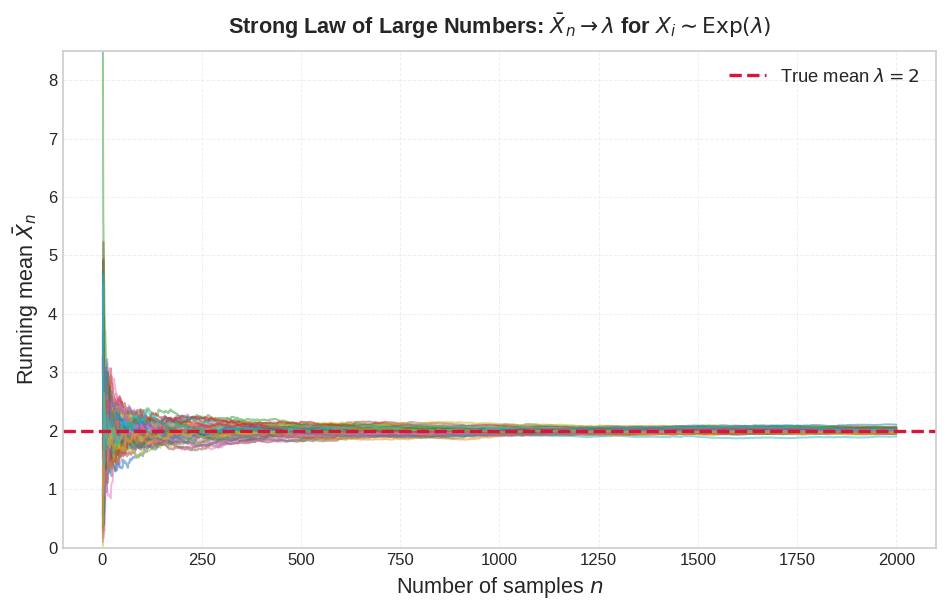

In [6]:
exp_gen = partial(sample_exponential, lambda_parameter)
n = 2000
n_indep_replicates = 50
nsample_arr = np.arange(1, n + 1)

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(8, 5.2), dpi=120)
for _ in range(n_indep_replicates):
    mc_exp = monte_carlo(n, exp_gen, lambda x: x, cumsum=True)
    plt.plot(nsample_arr, mc_exp.estimate, lw=1.2, alpha=0.5)

# --- True mean line ---
plt.axhline(y=lambda_parameter, color='crimson', lw=2.0, linestyle='--', label=r'True mean $\lambda=2$')

# --- Labels and title ---
plt.xlabel(r'Number of samples $n$', fontsize=13)
plt.ylabel(r'Running mean $\bar{X}_n$', fontsize=13)
plt.title(r'Strong Law of Large Numbers: $\bar{X}_n \to \lambda$ for $X_i \sim \mathrm{Exp}(\lambda)$',
          fontsize=13, weight='semibold', pad=10)

# --- Subtle grid and limits ---
plt.grid(alpha=0.3, linestyle='--', linewidth=0.6)
plt.ylim(0, 8.5)
plt.legend(frameon=False, fontsize=11, loc='best')

plt.tight_layout()
plt.savefig("images/exponential/SLLN_exp.png", dpi=300, bbox_inches="tight", facecolor='white')
plt.show()

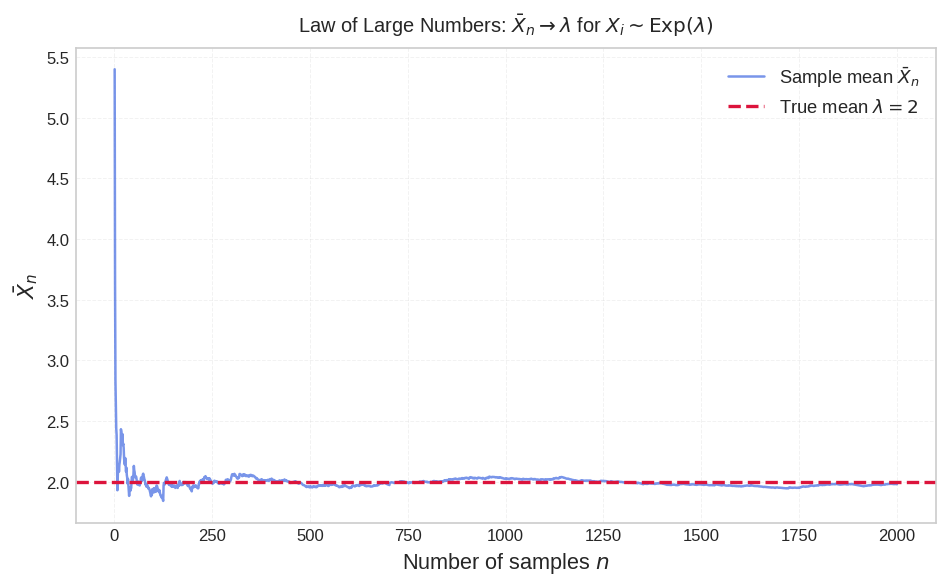

In [7]:
mc_exp = monte_carlo(2000, exp_gen, lambda x: x, cumsum=True)
nsample_arr = np.arange(1, mc_exp.estimate.shape[0] + 1) # an array of numbers form 1,2,...,nsamples

# Plot
plt.figure(figsize=(8, 5), dpi=120)
plt.plot(nsample_arr, mc_exp.estimate, color='royalblue', lw=1.5, alpha=0.7, label=r'Sample mean $\bar{X}_n$')
plt.axhline(y=2, color='crimson', lw=2.0, linestyle='--', label=r'True mean $\lambda=2$')


# Labels & title
plt.xlabel(r'Number of samples $n$', fontsize=13)
plt.ylabel(r'$\bar{X}_n$', fontsize=13)
plt.title(r'Law of Large Numbers: $\bar{X}_n \rightarrow \lambda$ for $X_i \sim \mathrm{Exp}(\lambda)$',
          fontsize=12, pad=10)

# Aesthetics
plt.grid(alpha=0.25, linestyle='--', linewidth=0.6)
plt.legend(frameon=False, fontsize=11, loc='best')
plt.tight_layout()

# Optional: use a nice style
plt.style.use('seaborn-v0_8-talk')
plt.show()

## Central Limit Theorem

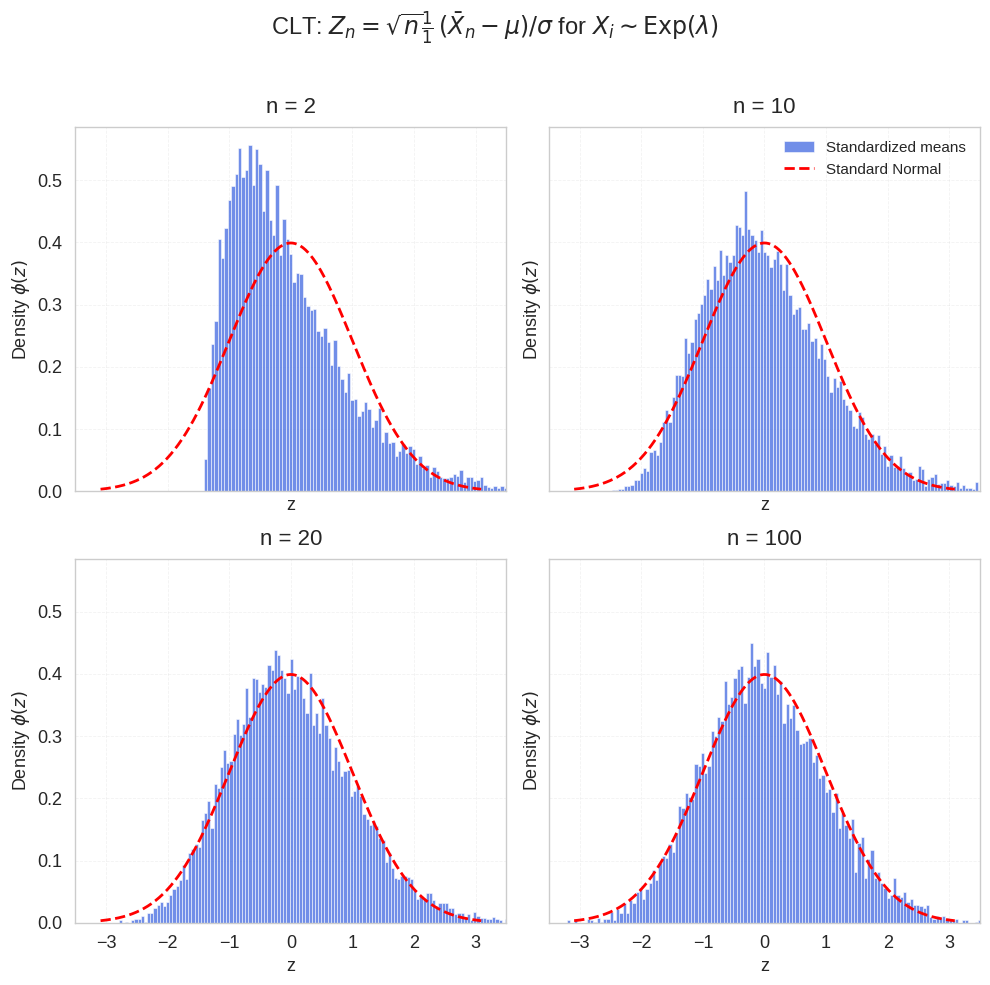

In [ ]:
exp_gen = partial(sample_exponential, lambda_parameter)
nsamples = np.array([[2, 10], [20, 100]])
ntrials = 10000
true_mean = lambda_parameter
std_deviation = lambda_parameter

# plt.style.use('seaborn-v0_8-talk')
fig, axs = plt.subplots(2, 2, figsize=(10, 10), sharex=True, sharey=True)

# Standard normal overlay (theoretical)
ppm_thresh = 1e-3
N = 300
x = np.linspace(scistats.norm.ppf(ppm_thresh), scistats.norm.ppf(1 - ppm_thresh), N)
norm_pdf = scistats.norm.pdf(x)

for i, n in np.ndenumerate(nsamples):
    z_estimates = normalize_sampling_distribution(n, ntrials, exp_gen, lambda x: x, true_mean, std_deviation)
    
    axs[i].hist(z_estimates, bins=150, density=True,
                color='royalblue', alpha=0.75, edgecolor='white', linewidth=0.5,
                label='Standardized means')
    axs[i].plot(x, norm_pdf, 'r--', lw=2, label='Standard Normal')
    
    axs[i].set_xlim(-3.5, 3.5) # common z-range
    axs[i].set_title(f"n = {n}", fontsize=16, pad=10)
    axs[i].set_xlabel("z", fontsize=13)
    axs[i].set_ylabel(r"Density $\phi(z)$", fontsize=13)
    axs[i].grid(alpha=0.25, linestyle='--', linewidth=0.6)

# Title + layout
fig.suptitle(r"CLT: $Z_n=\sqrt{n}\frac{(\bar{X}_n-\mu)}{1}\,/\sigma$ for $X_i \sim \mathrm{Exp}(\lambda)$",
             fontsize=17, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Legend once (upper-right panel)
axs[0, 1].legend(frameon=False, fontsize=11, loc='best')

# Save
plt.savefig("images/exponential/CLT_exp.png", dpi=300, bbox_inches="tight", facecolor='white')
plt.show()